# Force-Chain Analysis Pipeline 



## Imports

These packages handle tables, arrays, graph analysis, statistics, and plotting.


In [362]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Iterable

import numpy as np
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import seaborn as sns

try:
    import plotly.graph_objects as go
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except Exception as e:
    PLOTLY_AVAILABLE = False
    print("Plotly is not available. Interactive 3D/base figures will be skipped.")

try:
    from scipy.optimize import curve_fit
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    print("SciPy is not available. Exponential fits will be skipped.")

sns.set_context("talk")
sns.set_style("whitegrid")


## Configuration

This is the main cell to edit when you switch simulations. 

In [363]:
@dataclass
class PipelineConfig:
    
    particle_file: str = "dump_mu0.7_mur0.1_mut0.1.cor"
    contact_file: str = "dump_mu0.7_mur0.1_mut0.1.lst"
    output_dir: str = "force_chain_demo_output_max"

    # particle_file: str = "dump_mu0.1_mur0.0_mut0.0.cor"
    # contact_file: str = "dump_mu0.1_mur0.0_mut0.0.lst"
    # output_dir: str = "force_chain_demo_output_min"

    
    
    # Contact dump column indices after ITEM: ENTRIES.
    contact_i_col: int = 1
    contact_j_col: int = 2
    contact_force_col: int = 9 #normal force

    # Particle dump column indices after ITEM: ATOMS.
    atom_id_col: int = 0
    atom_x_col: int = 2
    atom_y_col: int = 3
    atom_z_col: int = 4

    # Force-chain detection settings.
    chain_percentile: float = 90.0      # top 10% by EBC
    angle_limit_deg: float = 45.0       # maximum local bend while walking chains
    min_chain_length: int = 3           # minimum particles per chain

    # Analysis settings.
    vertical_alignment_cutoff: float = 0.5
    z_floor: float = 0.0
    base_tolerance: float = 0.6

cfg = PipelineConfig()
output_dir = Path(cfg.output_dir)
output_dir.mkdir(parents=True, exist_ok=True)



print(cfg)



PipelineConfig(particle_file='dump_mu0.7_mur0.1_mut0.1.cor', contact_file='dump_mu0.7_mur0.1_mut0.1.lst', output_dir='force_chain_demo_output_max', contact_i_col=1, contact_j_col=2, contact_force_col=9, atom_id_col=0, atom_x_col=2, atom_y_col=3, atom_z_col=4, chain_percentile=90.0, angle_limit_deg=45.0, min_chain_length=3, vertical_alignment_cutoff=0.5, z_floor=0.0, base_tolerance=0.6)


## Step 2 — Helper functions

These small helpers keep edge names consistent and calculate local geometry.


In [364]:
PositionDict = Dict[int, np.ndarray]
EdgeKey = Tuple[int, int]

def edge_key(u: int, v: int) -> EdgeKey:
    """Consistent key for undirected edges."""
    return tuple(sorted((int(u), int(v))))

def unit_vector(vec: np.ndarray) -> np.ndarray:
    """Normalize a vector safely."""
    return vec / (np.linalg.norm(vec) + 1e-12)

def bend_angle_deg(pos_a: np.ndarray, pos_b: np.ndarray, pos_c: np.ndarray) -> float:
    """Angle between consecutive segments a->b and b->c.

    0 degrees means locally straight; larger values mean stronger bending.
    """
    v1 = unit_vector(pos_b - pos_a)
    v2 = unit_vector(pos_c - pos_b)
    dot = np.clip(np.dot(v1, v2), -1.0, 1.0)
    return float(np.degrees(np.arccos(dot)))


## Step 3 — Load particle positions

This reads the particle dump and stores each particle as

```python
positions[particle_id] = np.array([x, y, z])
```


In [365]:
def read_lammps_positions(filename: str, cfg: PipelineConfig) -> PositionDict:
    positions: PositionDict = {}
    reading_atoms = False

    with open(filename, "r") as f:
        for raw_line in f:
            line = raw_line.strip()

            if line.startswith("ITEM: ATOMS"):
                reading_atoms = True
                continue

            if line.startswith("ITEM:") and not line.startswith("ITEM: ATOMS"):
                reading_atoms = False
                continue

            if reading_atoms and line:
                parts = line.split()
                needed = max(cfg.atom_id_col, cfg.atom_x_col, cfg.atom_y_col, cfg.atom_z_col)
                if len(parts) <= needed:
                    continue

                pid = int(float(parts[cfg.atom_id_col]))
                positions[pid] = np.array([
                    float(parts[cfg.atom_x_col]),
                    float(parts[cfg.atom_y_col]),
                    float(parts[cfg.atom_z_col]),
                ], dtype=float)

    if not positions:
        raise ValueError(f"No particle positions found in {filename!r}.")

    return positions

pos= read_lammps_positions(cfg.particle_file, cfg)
print(f"Loaded {len(pos):,} particle positions.")
list(pos.items())[:3]



Loaded 2,669 particle positions.


[(79, array([3.22207 , 0.104462, 0.499992])),
 (112, array([4.88443 , 0.451472, 0.499914])),
 (12, array([6.81355 , 0.143821, 0.499985]))]

## Step 4 — Load contact forces

This reads contacts from the local dump. Each row becomes one contact edge with particles `i`, `j`, and force magnitude `F`.


In [366]:
def read_lammps_local_contacts(filename: str, cfg: PipelineConfig) -> pd.DataFrame:
    rows: List[List[str]] = []
    reading_entries = False

    with open(filename, "r") as f:
        for raw_line in f:
            line = raw_line.strip()

            if line.startswith("ITEM: ENTRIES"):
                reading_entries = True
                continue

            if line.startswith("ITEM:") and not line.startswith("ITEM: ENTRIES"):
                reading_entries = False
                continue

            if reading_entries and line:
                rows.append(line.split())

    if not rows:
        raise ValueError(f"No contact rows found in {filename!r}.")

    raw = pd.DataFrame(rows).astype(float)
    needed = max(cfg.contact_i_col, cfg.contact_j_col, cfg.contact_force_col)
    if raw.shape[1] <= needed:
        raise ValueError(f"Contact file has {raw.shape[1]} columns, but requested index {needed}.")

    contacts = pd.DataFrame({
        "i": raw[cfg.contact_i_col].astype(int),
        "j": raw[cfg.contact_j_col].astype(int),
        "F": raw[cfg.contact_force_col].astype(float),
    })

    contacts = contacts.replace([np.inf, -np.inf], np.nan).dropna()
    contacts = contacts[contacts["F"] > 0].copy()
    return contacts

contacts = read_lammps_local_contacts(cfg.contact_file, cfg)
print(f"Loaded {len(contacts):,} positive-force contacts.")
contacts.head()


Loaded 4,971 positive-force contacts.


,i,j,F
0,79,70,2.904950
1,79,1123,3.372920
2,112,523,0.102228
3,112,1064,2.223410
4,112,1148,4.607690


In [367]:
Favg = contacts['F'].mean()
print(Favg)

1.8866982396278416


## Step 5 — Build the contact graph

Particles are nodes. Contacts are edges. Each edge stores:

- `force = F`
- `weight = 1/F`

The inverse-force weight makes strong contacts behave like short paths, so shortest paths prefer high-force routes.


In [368]:
def build_contact_graph(contacts: pd.DataFrame) -> nx.Graph:
    G = nx.Graph()
    for row in contacts.itertuples(index=False):
        u, v, force = int(row.i), int(row.j), float(row.F)
        if u == v or force <= 0:
            continue
        G.add_edge(u, v, force=force, weight=1.0 / force)
    if G.number_of_edges() == 0:
        raise ValueError("Graph has no valid contact edges.")
    return G

G = build_contact_graph(contacts)
print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")


Graph nodes: 2,611
Graph edges: 4,971


## Step 6 — Compute weighted edge betweenness centrality

Edge betweenness centrality asks: **which contacts lie on many important shortest paths?**

Because the shortest-path weight is \(1/F\), high-force contacts are favored in the transport network.


In [369]:
def compute_edge_betweenness(G: nx.Graph) -> Dict[EdgeKey, float]:
    ebc_raw = nx.edge_betweenness_centrality(G, weight="weight")
    return {edge_key(u, v): float(value) for (u, v), value in ebc_raw.items()}

ebc = compute_edge_betweenness(G)
ebc_values = np.array(list(ebc.values()))
print(f"Computed EBC for {len(ebc):,} edges.")
print(f"EBC range: {ebc_values.min():.3g} to {ebc_values.max():.3g}")


Computed EBC for 4,971 edges.
EBC range: 0 to 0.124


## Step 7 — Select the force-chain backbone

Here we keep the top percentile of edges by EBC. This is the structural backbone used for chain extraction.


In [370]:
def make_backbone_graph(G: nx.Graph, ebc: Dict[EdgeKey, float], percentile: float) -> Tuple[nx.Graph, float]:
    values = np.array(list(ebc.values()), dtype=float)
    threshold = float(np.percentile(values, percentile))
    H = nx.Graph()

    for u, v, data in G.edges(data=True):
        k = edge_key(u, v)
        if ebc.get(k, 0.0) >= threshold:
            H.add_edge(u, v, **data, ebc=ebc[k])

    return H, threshold

H, ebc_threshold = make_backbone_graph(G, ebc, cfg.chain_percentile)
print(f"EBC threshold: {ebc_threshold:.4g}")
print(f"Backbone edges: {H.number_of_edges():,}")
print(f"Backbone nodes: {H.number_of_nodes():,}")


EBC threshold: 0.007182
Backbone edges: 498
Backbone nodes: 457


## Step 8 — Walk locally straight force chains

This converts the high-EBC backbone into individual chains. Starting from the most central edges, the algorithm extends a chain by choosing the neighbor that creates the smallest bend angle. A step is accepted only if the bend is below `angle_limit_deg`.


In [371]:
def choose_next_node(H: nx.Graph, positions: PositionDict, chain: List[int], direction: str, angle_limit_deg: float):
    tip = chain[-1] if direction == "head" else chain[0]
    prev = chain[-2] if direction == "head" else chain[1]

    if tip not in positions or prev not in positions:
        return None

    best_node = None
    best_angle = angle_limit_deg

    for nb in H.neighbors(tip):
        if nb in chain or nb not in positions:
            continue

        if direction == "head":
            angle = bend_angle_deg(positions[prev], positions[tip], positions[nb])
        else:
            angle = bend_angle_deg(positions[nb], positions[tip], positions[prev])

        if angle < best_angle:
            best_angle = angle
            best_node = int(nb)

    return best_node


def extract_force_chains(H: nx.Graph, positions: PositionDict, cfg: PipelineConfig) -> List[List[int]]:
    chains: List[List[int]] = []
    visited_edges: set[EdgeKey] = set()

    sorted_edges = sorted(H.edges(data=True), key=lambda item: item[2].get("ebc", 0.0), reverse=True)

    for u, v, _ in sorted_edges:
        if edge_key(u, v) in visited_edges:
            continue

        chain = [int(u), int(v)]
        visited_edges.add(edge_key(u, v))

        for direction in ("head", "tail"):
            while True:
                tip = chain[-1] if direction == "head" else chain[0]
                next_node = choose_next_node(H, positions, chain, direction, cfg.angle_limit_deg)
                if next_node is None:
                    break

                visited_edges.add(edge_key(tip, next_node))
                if direction == "head":
                    chain.append(next_node)
                else:
                    chain.insert(0, next_node)

        if len(chain) >= cfg.min_chain_length:
            chains.append(chain)

    return chains

chains = extract_force_chains(H, pos, cfg)

lengths = [len(c) for c in chains]

print(f"Extracted {len(chains):,} chains.")
print(f"Mean chain length: {np.mean(lengths):.2f} particles")
print(f"Max chain length: {np.max(lengths)} particles")
chains[:3]


# chains_high = extract_force_chains(H, pos_high, cfg)
# lengths_high = [len(c) for c in chains_high]
# print(f"Extracted {len(chains_high):,} chains (high).")
# print(f"Mean chain length: {np.mean(lengths_high):.2f} particles")
# print(f"Max chain length: {np.max(lengths_high)} particles")
# chains_high[:3]

# chains_low = extract_force_chains(H, pos_low, cfg)
# lengths_low = [len(c) for c in chains_low]
# print(f"Extracted {len(chains_low):,} chains (low).")

# print(f"Mean chain length: {np.mean(lengths_low):.2f} particles")
# print(f"Max chain length: {np.max(lengths_low)} particles")
# chains_low[:3]


Extracted 128 chains.
Mean chain length: 3.92 particles
Max chain length: 8 particles


[[402, 932, 385, 368], [642, 1091, 734], [586, 643, 326, 932]]

## Step 9 — Build metric tables

These tables make the analysis easier to plot and export.

- `edge_df`: one row per contact edge
- `segment_df`: one row per local chain bend
- `chain_df`: one row per full chain
- `coord_df`: one row per particle coordination number
- `base_df`: one row per near-floor particle


In [372]:
def summarize_chain_edges(G: nx.Graph, H: nx.Graph, ebc: Dict[EdgeKey, float]) -> pd.DataFrame:
    backbone_edges = {edge_key(u, v) for u, v in H.edges()}
    rows = []
    for u, v, data in G.edges(data=True):
        k = edge_key(u, v)
        rows.append({
            "i": k[0], "j": k[1],
            "F": data["force"],
            "weight_1_over_F": data["weight"],
            "edge_betweenness": ebc.get(k, np.nan),
            "in_backbone": k in backbone_edges,
        })
    return pd.DataFrame(rows)


def compute_segment_metrics(chains: List[List[int]], positions: PositionDict, G: nx.Graph) -> pd.DataFrame:
    rows = []
    for chain_id, chain in enumerate(chains):
        for local_idx in range(1, len(chain) - 1):
            p1, p2, p3 = chain[local_idx - 1], chain[local_idx], chain[local_idx + 1]
            if p1 not in positions or p2 not in positions or p3 not in positions:
                continue
            if not (G.has_edge(p1, p2) and G.has_edge(p2, p3)):
                continue

            angle = bend_angle_deg(positions[p1], positions[p2], positions[p3])
            f1 = G[p1][p2]["force"]
            f2 = G[p2][p3]["force"]
            seg_vec = positions[p2] - positions[p1]
            vertical_alignment = abs(float(unit_vector(seg_vec)[2]))

            rows.append({
                "chain_id": chain_id,
                "local_index": local_idx,
                "p1": p1, "p2": p2, "p3": p3,
                "bend_angle_deg": angle,
                "avg_force": 0.5 * (f1 + f2),
                "vertical_alignment_abs_cos": vertical_alignment,
            })
    return pd.DataFrame(rows)


def compute_chain_metrics(chains: List[List[int]], positions: PositionDict, G: nx.Graph) -> pd.DataFrame:
    rows = []
    for chain_id, chain in enumerate(chains):
        valid = [p for p in chain if p in positions]
        if len(valid) < 2:
            continue

        start, end = valid[0], valid[-1]
        end_to_end = positions[end] - positions[start]
        straight_length = float(np.linalg.norm(end_to_end))
        actual_length = 0.0
        edge_forces = []

        for a, b in zip(valid[:-1], valid[1:]):
            actual_length += float(np.linalg.norm(positions[b] - positions[a]))
            if G.has_edge(a, b):
                edge_forces.append(float(G[a][b]["force"]))

        vec_u = unit_vector(end_to_end)
        orientation_from_vertical_deg = float(np.degrees(np.arccos(np.clip(abs(vec_u[2]), -1.0, 1.0))))
        tortuosity = actual_length / (straight_length + 1e-12)

        rows.append({
            "chain_id": chain_id,
            "n_particles": len(valid),
            "n_edges": max(len(valid) - 1, 0),
            "start_particle": start,
            "end_particle": end,
            "actual_length": actual_length,
            "straight_length": straight_length,
            "tortuosity": tortuosity,
            "orientation_from_vertical_deg": orientation_from_vertical_deg,
            "mean_chain_force": np.mean(edge_forces) if edge_forces else np.nan,
            "max_chain_force": np.max(edge_forces) if edge_forces else np.nan,
        })
    return pd.DataFrame(rows)


def compute_coordination_summary(G: nx.Graph, chains: List[List[int]]) -> pd.DataFrame:
    chain_particles = {p for chain in chains for p in chain}
    return pd.DataFrame([
        {"particle_id": int(node), "coordination_number": int(degree), "in_force_chain": node in chain_particles}
        for node, degree in G.degree()
    ])


def compute_base_pressure(G: nx.Graph, positions: PositionDict, cfg: PipelineConfig) -> pd.DataFrame:
    """Estimate base pressure from contacts on particles close to the floor.

    If the contact dump only contains force magnitude, the vertical contribution is estimated by projecting
    along the center-to-center direction: Fz_est = F * |dz| / distance.
    """
    rows = []
    for node in G.nodes():
        if node not in positions:
            continue
        x, y, z = positions[node]
        if abs(z - cfg.z_floor) > cfg.base_tolerance:
            continue

        fz_sum = 0.0
        for nb in G.neighbors(node):
            if nb not in positions:
                continue
            dvec = positions[nb] - positions[node]
            dist = np.linalg.norm(dvec) + 1e-12
            f = G[node][nb]["force"]
            fz_sum += f * abs(dvec[2]) / dist

        rows.append({"particle_id": int(node), "x": x, "y": y, "z": z, "base_force_z_est": fz_sum})
    return pd.DataFrame(rows)

edge_df = summarize_chain_edges(G, H, ebc)
segment_df = compute_segment_metrics(chains, pos, G)
chain_df = compute_chain_metrics(chains, pos, G)
coord_df = compute_coordination_summary(G, chains)
base_df = compute_base_pressure(G, pos, cfg)

print("edge_df", edge_df.shape)
print("segment_df", segment_df.shape)
print("chain_df", chain_df.shape)
print("coord_df", coord_df.shape)
print("base_df", base_df.shape)
chain_df.head()


edge_df (4971, 6)
segment_df (246, 8)
chain_df (128, 11)
coord_df (2611, 3)
base_df (289, 5)


,chain_id,n_particles,n_edges,start_particle,end_particle,actual_length,straight_length,tortuosity,orientation_from_vertical_deg,mean_chain_force,max_chain_force
0,0,4,3,402,368,2.999628,2.818657,1.064205,87.426508,11.346927,15.92500
1,1,3,2,642,734,1.999823,1.886713,1.059951,71.727299,7.832415,8.44646
2,2,4,3,586,932,2.999638,2.934420,1.022225,85.276138,9.718403,12.99900
3,3,4,3,711,1587,2.999715,2.763406,1.085514,24.087360,9.004973,11.26990
4,4,4,3,110,1311,2.999597,2.968717,1.010402,36.938867,13.041957,15.21850


# Figure set

The next sections generate the figures you specifically wanted to preserve for demos and explanations.


## Figure 1 — Force comparison: all contacts vs. force-chain contacts

This checks whether the detected chains are actually the heavy-lifting part of the system.


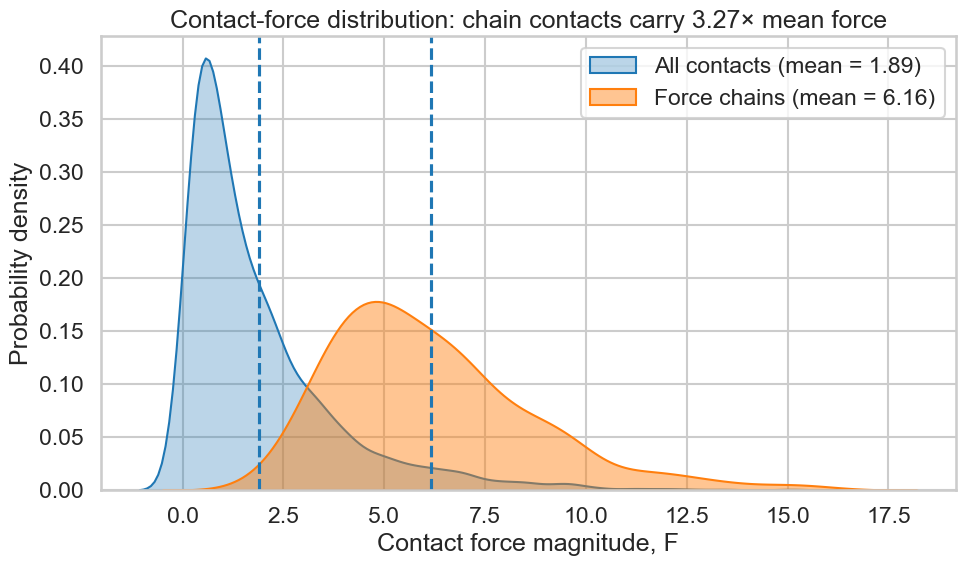

Mean all-contact force: 1.887
Mean chain-contact force: 6.163
Force ratio, chains/all: 3.266


In [373]:
def get_chain_contact_forces(G: nx.Graph, chains: List[List[int]]) -> np.ndarray:
    chain_forces = []
    for chain in chains:
        for u, v in zip(chain[:-1], chain[1:]):
            if G.has_edge(u, v):
                chain_forces.append(G[u][v]["force"])
    return np.asarray(chain_forces, dtype=float)


def plot_force_pdf_comparison(G: nx.Graph, chains: List[List[int]], save_path: Path | None = None):
    all_forces = np.asarray([d["force"] for _, _, d in G.edges(data=True)], dtype=float)
    chain_forces = get_chain_contact_forces(G, chains)

    avg_all = np.mean(all_forces)
    avg_chain = np.mean(chain_forces)
    ratio = avg_chain / avg_all if avg_all > 0 else np.nan

    plt.figure(figsize=(10, 6))
    sns.kdeplot(all_forces, label=f"All contacts (mean = {avg_all:.2f})", fill=True, alpha=0.30)
    sns.kdeplot(chain_forces, label=f"Force chains (mean = {avg_chain:.2f})", fill=True, alpha=0.45)
    plt.axvline(avg_all, linestyle="--")
    plt.axvline(avg_chain, linestyle="--")
    plt.title(f"Contact-force distribution: chain contacts carry {ratio:.2f}× mean force")
    plt.xlabel("Contact force magnitude, F")
    plt.ylabel("Probability density")
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Mean all-contact force: {avg_all:.3f}")
    print(f"Mean chain-contact force: {avg_chain:.3f}")
    print(f"Force ratio, chains/all: {ratio:.3f}")

plot_force_pdf_comparison(G, chains, output_dir / "force_pdf_comparison.png")


## Figure 2 — Local chain linearity

This asks whether force chains are straight, bent, or mesh-like. A bend angle near \(0^\circ\) means locally straight.


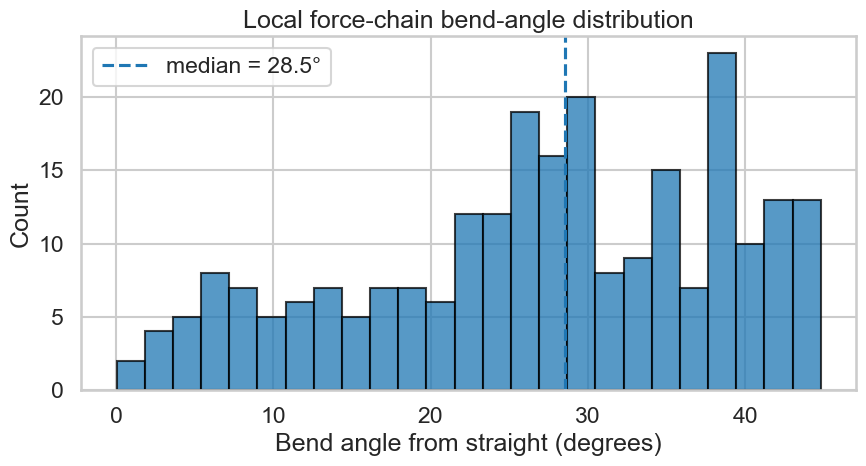

In [374]:
def plot_chain_bend_histogram(segment_df: pd.DataFrame, save_path: Path | None = None):
    if segment_df.empty:
        print("No segment angles to plot.")
        return

    angles = segment_df["bend_angle_deg"].dropna().to_numpy()
    plt.figure(figsize=(9, 5))
    counts, bins, patches=plt.hist(angles, bins=25, alpha=0.75, edgecolor="black")
    plt.axvline(np.median(angles), linestyle="--", label=f"median = {np.median(angles):.1f}°")
    max_index=np.argmax(counts)
    #patches[max_index].set_facecolor("crimson")
    #patches[max_index].set_edgecolor("darkred")
    #patches[max_index].set_linewidth(2)

    #plt.axvline(np.max(max_index), linestyle="--", label=f"max_index = {np.max(max_index):.1f}°")
    plt.title("Local force-chain bend-angle distribution")
    plt.xlabel("Bend angle from straight (degrees)")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

plot_chain_bend_histogram(segment_df, output_dir / "bend_angle_histogram.png")


## Figure 3 — Bend angle vs. force

This tests whether straighter local segments carry more force. The same function can also focus on approximately vertical segments.


All chain segments: slope = -0.0244, Pearson r = -0.1325


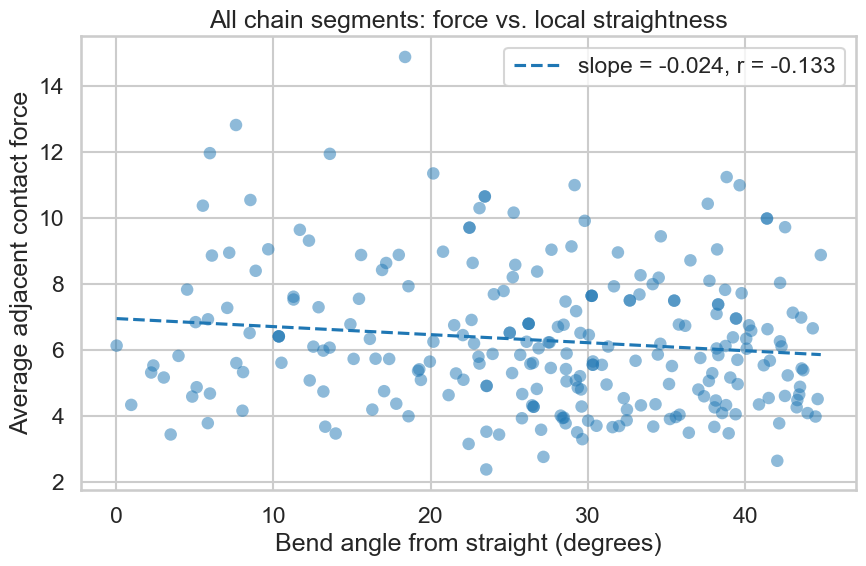

Approximately vertical chain segments: slope = -0.0327, Pearson r = -0.1772


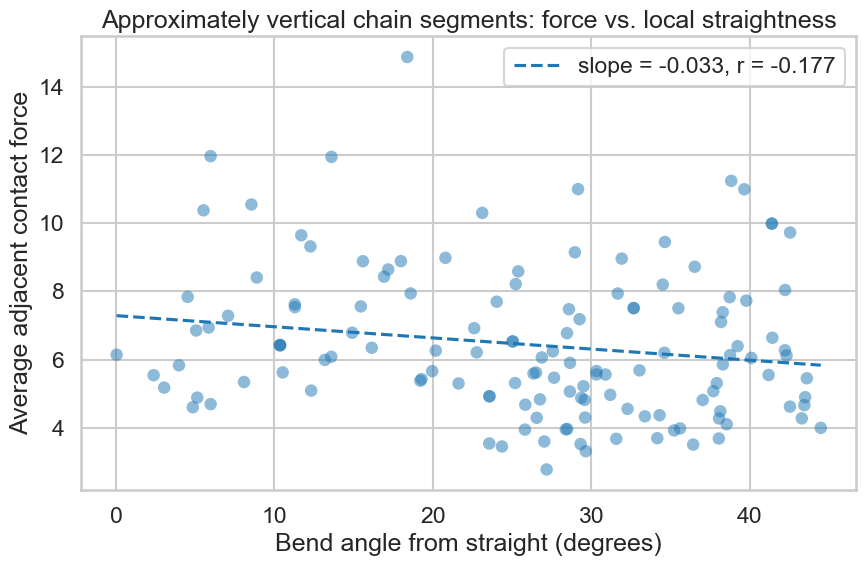

In [375]:
def plot_angle_vs_force(segment_df: pd.DataFrame, vertical_only: bool = False, save_path: Path | None = None):
    data = segment_df.copy()
    title_prefix = "All chain segments"

    if vertical_only:
        data = data[data["vertical_alignment_abs_cos"] >= cfg.vertical_alignment_cutoff]
        title_prefix = "Approximately vertical chain segments"

    if data.empty:
        print("No data to plot.")
        return

    x = data["bend_angle_deg"].to_numpy()
    y = data["avg_force"].to_numpy()

    plt.figure(figsize=(9, 6))
    plt.scatter(x, y, alpha=0.5, edgecolors="none")

    if len(data) > 2:
        coeff = np.polyfit(x, y, 1)
        fit = np.poly1d(coeff)
        xx = np.linspace(np.min(x), np.max(x), 100)
        corr = np.corrcoef(x, y)[0, 1]
        plt.plot(xx, fit(xx), linestyle="--", label=f"slope = {coeff[0]:.3f}, r = {corr:.3f}")
        plt.legend()
        print(f"{title_prefix}: slope = {coeff[0]:.4f}, Pearson r = {corr:.4f}")

    plt.title(f"{title_prefix}: force vs. local straightness")
    plt.xlabel("Bend angle from straight (degrees)")
    plt.ylabel("Average adjacent contact force")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

plot_angle_vs_force(segment_df, vertical_only=False, save_path=output_dir / "angle_vs_force.png")
plot_angle_vs_force(segment_df, vertical_only=True, save_path=output_dir / "angle_vs_force_vertical_only.png")


## Figure 4 — 3D chain architecture

This is the presentation figure showing the extracted chains embedded in the full particle cloud. Chains are colored by mean chain force.


In [376]:
def visualize_3d_chain_architecture(pos: PositionDict, chains: List[List[int]], G: nx.Graph, save_html: Path | None = None):
    if not PLOTLY_AVAILABLE:
        print("Plotly not available; skipping 3D figure.")
        return

    fig = go.Figure()

    pts = np.array(list(pos.values()))
    fig.add_trace(go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers",
        marker=dict(size=1.5, color="lightgray", opacity=0.035),
        name="Background particles",
        hoverinfo="skip",
    ))

    chain_forces = []
    for c in chains:
        forces = [G[c[i]][c[i+1]]["force"] for i in range(len(c)-1) if G.has_edge(c[i], c[i+1])]
        forcesAvg = forces/Favg
        print(forcesAvg)
        #chain_forces.append(np.mean(forces) if forces else 0.0)
        chain_forces.append(np.mean(forces) if forces else 0.0)

    if len(chain_forces) == 0:
        print("No chains to visualize.")
        return

    norm = mcolors.Normalize(vmin=min(chain_forces), vmax=max(chain_forces) + 1e-12)

    for i, c in enumerate(chains):
        c_pts = np.array([pos[p] for p in c if p in pos])
        if len(c_pts) == 0:
            continue
        rgba = cm.inferno(norm(chain_forces[i]))
        hex_color = mcolors.to_hex(rgba)

        fig.add_trace(go.Scatter3d(
            x=c_pts[:, 0], y=c_pts[:, 1], z=c_pts[:, 2],
            mode="lines+markers",
            line=dict(color=hex_color, width=8),
            marker=dict(size=4, color=hex_color, opacity=1, line=dict(color="black", width=1)),
            name=f"Chain {i}",
            text=f"Chain {i}<br>Mean force: {chain_forces[i]:.2f}<br>Particles: {len(c)}",
            hoverinfo="text",
        ))

    # dummy trace for colorbar
    fig.add_trace(go.Scatter3d(
        x=[None], y=[None], z=[None], mode="markers",
        marker=dict(
            #colorscale="Inferno_r",
            colorscale="Plasma_r",
            showscale=True,
            cmin=min(chain_forces),
            cmax=max(chain_forces),
            colorbar=dict(title="Mean chain force", thickness=20, len=0.8),
        ),
        showlegend=False,
    ))

    fig.update_layout(
        title="3D force-chain architecture",
        template="plotly_white",
        scene=dict(
            xaxis=dict(title="x"),
            yaxis=dict(title="y"),
            zaxis=dict(title="z"),
            bgcolor="white",
        ),
        margin=dict(l=0, r=0, b=0, t=55),
        showlegend=False,
    )

    if save_html:
        fig.write_html(str(save_html))
        print(f"Saved interactive figure to {save_html}")

    fig.show()

visualize_3d_chain_architecture(pos, chains, G, save_html=output_dir / "chain_architecture_3d.html")


[8.44067147 5.15674939 4.44509346]
[3.82592714 4.47684734]
[5.15207986 6.88981403 3.41113903]
[4.62067002 5.97334527 3.72460728]
[8.06620777 7.71676132 4.95477751]
[3.25556566 2.82833783 5.76552189 5.01839128]
[1.94873241 3.69882149]
[3.73017786 3.18641841 2.92821071]
[2.86919757 2.1690008 ]
[3.56009767 2.9218345 ]
[4.47615301 7.18641684 3.74076779 3.03732196 3.47428638 3.56567885]
[6.40144764 3.10274843 2.27385064 2.98824681]
[6.39620038 3.02655182 3.5447534  4.20035374]
[4.52905495 4.99944814 4.60676213 4.79756636 2.3911349  1.76296343]
[6.17814749 5.01083311]
[5.49372432 2.58837895 2.57578552]
[6.22664492 5.07622777 3.41022208]
[6.31394027 4.69264762 4.22241344 3.13505884]
[4.24488656 3.68330762 5.25812755]
[4.2878452  5.20756833 5.86076765 4.45490425 2.1608861 ]
[1.98539964 4.51500925 3.44178516]
[4.36563189 3.90050186 2.57872716 2.34378233]
[7.2596665  5.43356631]
[3.94693748 2.27835056 4.88757545 2.94702135]
[2.70273746 2.12636548]
[2.9840861  2.95054603]
[2.89736847 1.20543389 2

#fixed axes
def visualize_3d_chain_architecture(pos: PositionDict, chains: List[List[int]], G: nx.Graph, save_html: Path | None = None):
    if not PLOTLY_AVAILABLE:
        print("Plotly not available; skipping 3D figure.")
        return

    fig = go.Figure()

    pts = np.array(list(pos.values()))
    fig.add_trace(go.Scatter3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        mode="markers",
        marker=dict(
            size=1.5,
            color="lightgray",
            opacity=0.035
        ),
        name="Background particles",
        hoverinfo="skip",
    ))

    chain_forces = []
    for c in chains:
        forces = [
            G[c[i]][c[i+1]]["force"]
            for i in range(len(c)-1)
            if G.has_edge(c[i], c[i+1])
        ]
        chain_forces.append(np.mean(forces) if forces else 0.0)

    if len(chain_forces) == 0:
        print("No chains to visualize.")
        return

    # FIXED color scale: 0 to 15
    norm = mcolors.Normalize(vmin=0, vmax=15)

    for i, c in enumerate(chains):
        c_pts = np.array([pos[p] for p in c if p in pos])
        if len(c_pts) == 0:
            continue

        rgba = cm.inferno(norm(chain_forces[i]))
        hex_color = mcolors.to_hex(rgba)

        fig.add_trace(go.Scatter3d(
            x=c_pts[:, 0],
            y=c_pts[:, 1],
            z=c_pts[:, 2],
            mode="lines+markers",
            line=dict(
                color=hex_color,
                width=8
            ),
            marker=dict(
                size=4,
                color=hex_color,
                opacity=1,
                line=dict(color="black", width=1)
            ),
            name=f"Chain {i}",
            text=f"Chain {i}<br>Mean force: {chain_forces[i]:.2f}<br>Particles: {len(c)}",
            hoverinfo="text",
        ))

    # Dummy trace for fixed colorbar
    fig.add_trace(go.Scatter3d(
        x=[None],
        y=[None],
        z=[None],
        mode="markers",
        marker=dict(
            colorscale="Inferno",
            showscale=True,
            cmin=0,
            cmax=15,
            color=[0],  # required to trigger colorbar
            colorbar=dict(
                title="Mean chain force",
                thickness=20,
                len=0.8
            ),
        ),
        showlegend=False,
    ))

    fig.update_layout(
        title="3D force-chain architecture",
        template="plotly_white",
        scene=dict(
            xaxis=dict(title="x"),
            yaxis=dict(title="y"),
            zaxis=dict(
                title="z",
                range=[0, 8]   # FIXED z axis
            ),
            bgcolor="white",
        ),
        margin=dict(l=0, r=0, b=0, t=55),
        showlegend=False,
    )

    if save_html:
        fig.write_html(str(save_html))
        print(f"Saved interactive figure to {save_html}")
    fig.write_image("output.png", scale=1, width=1800, height=1500)
    fig.show()
    

visualize_3d_chain_architecture(
    pos,
    chains,
    G,
    save_html=output_dir / "chain_architecture_3d.html"
)

In [377]:
#in addition to html save an image
def visualize_3d_chain_architecture(
    pos: PositionDict,
    chains: List[List[int]],
    G: nx.Graph,
    save_html: Path | None = None,
    save_png: Path | None = None,
):
    if not PLOTLY_AVAILABLE:
        print("Plotly not available; skipping 3D figure.")
        return

    fig = go.Figure()

    pts = np.array(list(pos.values()))
    fig.add_trace(go.Scatter3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        mode="markers",
        marker=dict(
            size=1.5,
            color="lightgray",
            opacity=0.035
        ),
        name="Background particles",
        hoverinfo="skip",
    ))

    chain_forces = []
    for c in chains:
        forces = [
            G[c[i]][c[i+1]]["force"]
            for i in range(len(c)-1)
            if G.has_edge(c[i], c[i+1])
        ]
        chain_forces.append(np.mean(forces) if forces else 0.0)

    if len(chain_forces) == 0:
        print("No chains to visualize.")
        return

    norm = mcolors.Normalize(vmin=0, vmax=15)

    for i, c in enumerate(chains):
        c_pts = np.array([pos[p] for p in c if p in pos])
        if len(c_pts) == 0:
            continue

        rgba = cm.inferno(norm(chain_forces[i]))
        hex_color = mcolors.to_hex(rgba)

        fig.add_trace(go.Scatter3d(
            x=c_pts[:, 0],
            y=c_pts[:, 1],
            z=c_pts[:, 2],
            mode="lines+markers",
            line=dict(color=hex_color, width=8),
            marker=dict(
                size=4,
                color=hex_color,
                opacity=1,
                line=dict(color="black", width=1)
            ),
            name=f"Chain {i}",
            text=f"Chain {i}<br>Mean force: {chain_forces[i]:.2f}<br>Particles: {len(c)}",
            hoverinfo="text",
        ))

    fig.add_trace(go.Scatter3d(
        x=[None],
        y=[None],
        z=[None],
        mode="markers",
        marker=dict(
            colorscale="Inferno_r",
            #colorscale="Plasma_r",
            showscale=True,
            cmin=0,
            cmax=15,
            color=[0],
            colorbar=dict(
                title="Mean chain force",
                thickness=20,
                len=0.8
            ),
        ),
        showlegend=False,
    ))

    fig.update_layout(
        title="3D force-chain architecture",
        template="plotly_white",
        scene=dict(
            xaxis=dict(title="x"),
            yaxis=dict(title="y"),
            zaxis=dict(title="z", range=[0, 8]),
            bgcolor="white",
        ),
        margin=dict(l=0, r=0, b=0, t=55),
        showlegend=False,
    )

    # Save interactive HTML
    if save_html:
        fig.write_html(str(save_html))
        print(f"Saved interactive figure to {save_html}")

    # Save static PNG
    if save_png:
        fig.write_image(str(save_png), width=2000, height=1800, scale=2)
        print(f"Saved static image to {save_png}")

    fig.show()


visualize_3d_chain_architecture(
    pos,
    chains,
    G,
    save_html=output_dir / "chain_architecture_3d.html",
    save_png=output_dir / "chain_architecture_3d.png",
)

Saved interactive figure to force_chain_demo_output_max/chain_architecture_3d.html
Saved static image to force_chain_demo_output_max/chain_architecture_3d.png


In [378]:
def visualize_3d_chain_architecture_by_ebc(
    pos: PositionDict,
    chains: List[List[int]],
    G: nx.Graph,
    ebc: Dict[EdgeKey, float],
    save_html: Path | None = None,
    save_png: Path | None = None,
):
    if not PLOTLY_AVAILABLE:
        print("Plotly not available; skipping 3D figure.")
        return

    fig = go.Figure()

    # Background particles
    pts = np.array(list(pos.values()))
    fig.add_trace(go.Scatter3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        mode="markers",
        marker=dict(size=1.5, color="lightgray", opacity=0.035),
        name="Background particles",
        hoverinfo="skip",
    ))

    # Mean edge betweenness per chain
    chain_ebc = []
    for c in chains:
        vals = []
        for a, b in zip(c[:-1], c[1:]):
            if G.has_edge(a, b):
                vals.append(ebc.get(edge_key(a, b), G[a][b].get("ebc", 0.0)))
        chain_ebc.append(np.mean(vals) if vals else 0.0)

    if len(chain_ebc) == 0:
        print("No chains to visualize.")
        return

    vmin = min(chain_ebc)
    vmax = max(chain_ebc) + 1e-12
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i, c in enumerate(chains):
        valid_nodes = [p for p in c if p in pos]
        if len(valid_nodes) < 2:
            continue

        c_pts = np.array([pos[p] for p in valid_nodes])

        rgba = cm.viridis(norm(chain_ebc[i]))
        #rgba = cm.plasma(norm(chain_ebc[i]))
        hex_color = mcolors.to_hex(rgba)

        fig.add_trace(go.Scatter3d(
            x=c_pts[:, 0],
            y=c_pts[:, 1],
            z=c_pts[:, 2],
            mode="lines+markers",
            line=dict(color=hex_color, width=8),
            marker=dict(
                size=4,
                color=hex_color,
                opacity=1,
                line=dict(color="black", width=1)
            ),
            name=f"Chain {i}",
            text=(
                f"Chain {i}"
                f"<br>Mean edge betweenness: {chain_ebc[i]:.4g}"
                f"<br>Particles: {len(c)}"
                f"<br>Edges: {max(len(c)-1, 0)}"
            ),
            hoverinfo="text",
        ))

    # Dummy trace for colorbar
    fig.add_trace(go.Scatter3d(
        x=[None],
        y=[None],
        z=[None],
        mode="markers",
        marker=dict(
            colorscale="Viridis_r",
            #colorscale="Plasma_r",
            #colorscale="Inferno_r",
            showscale=True,
            cmin=vmin,
            cmax=vmax,
            color=[vmin],
            colorbar=dict(
                title="Mean chain EBC",
                thickness=20,
                len=0.8
            ),
        ),
        showlegend=False,
    ))

    fig.update_layout(
        title="3D force-chain architecture colored by edge betweenness",
        template="plotly_white",
        scene=dict(
            xaxis=dict(title="x"),
            yaxis=dict(title="y"),
            zaxis=dict(title="z", range=[0, 8]),
            bgcolor="white",
        ),
        margin=dict(l=0, r=0, b=0, t=55),
        showlegend=False,
    )

    if save_html:
        fig.write_html(str(save_html))
        print(f"Saved interactive figure to {save_html}")

    if save_png:
        fig.write_image(str(save_png), width=2000, height=1800, scale=2)
        print(f"Saved static image to {save_png}")

    fig.show()

In [379]:
visualize_3d_chain_architecture_by_ebc(
    pos,
    chains,
    G,
    ebc,
    save_html=output_dir / "chain_architecture_3d_by_ebc.html",
    save_png=output_dir / "chain_architecture_3d_by_ebc.png",
)

Saved interactive figure to force_chain_demo_output_max/chain_architecture_3d_by_ebc.html
Saved static image to force_chain_demo_output_max/chain_architecture_3d_by_ebc.png


In [380]:
def visualize_3d_chain_architecture(
    pos,
    chains,
    G,
    #
    #color by ebc
    #
    ebc,
    save_html=None,
    save_png=None,
):
    import numpy as np
    import plotly.graph_objects as go
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    fig = go.Figure()

    # ============================================================
    # 1. Store selected chain edges
    # ============================================================
    selected_edges = set()

    for c in chains:
        for i in range(len(c) - 1):
            a, b = c[i], c[i + 1]
            selected_edges.add(tuple(sorted((a, b))))

    # ============================================================
    # 2. Draw full background contact network in gray
    # ============================================================
    bg_x, bg_y, bg_z = [], [], []

    for a, b in G.edges():

        # Do not draw selected chain edges in gray
        if tuple(sorted((a, b))) in selected_edges:
            continue

        if a not in pos or b not in pos:
            continue

        # pa, pb = pos[a], pos[b]

        # bg_x += [pa[0], pb[0], None]
        # bg_y += [pa[1], pb[1], None]
        # bg_z += [pa[2], pb[2], None]
    #########
        pa, pb = pos[a], pos[b]
        
    # Remove long periodic-boundary gray edges

        #Lx = max(p[0] for p in pos.values()) - min(p[0] for p in pos.values())
        #Ly = max(p[1] for p in pos.values()) - min(p[1] for p in pos.values())
        dx = abs(pa[0] - pb[0])
        dy = abs(pa[1] - pb[1])
        #if dx > 0.5 * Lx or dy > 0.5 * Ly:
        #    continue
        

        if dx > 10 or dy > 10:
            continue

        bg_x += [pa[0], pb[0], None]
        bg_y += [pa[1], pb[1], None]
        bg_z += [pa[2], pb[2], None]
    ########


    
    fig.add_trace(go.Scatter3d(
        x=bg_x,
        y=bg_y,
        z=bg_z,
        mode="lines",
        line=dict(
            color="rgb(135,135,135)",
            width=1,
        ),
        opacity=0.35,
        name="Background contacts",
        hoverinfo="skip",
        showlegend=False,
    ))

    # ============================================================
    # 3. Build selected chain edge records
    # ============================================================
    edge_records = []

    for chain_id, c in enumerate(chains):
        for i in range(len(c) - 1):
            a, b = c[i], c[i + 1]

            if not G.has_edge(a, b):
                continue

            if a not in pos or b not in pos:
                continue

            # F = G[a][b].get("force", np.nan)

            # if not np.isfinite(F) or F <= 0:
            #     continue

            # logF = np.log10(F)

            # edge_records.append((chain_id, a, b, F, logF))

            #
            #color by ebc
            #
            F = G[a][b].get("force", np.nan)
            
            B = ebc.get(tuple(sorted((a, b))), np.nan)

            if not np.isfinite(B) or B <= 0:
                continue
            
            logB = np.log10(B)
            
            edge_records.append((chain_id, a, b, F, B, logB))

    
    if len(edge_records) == 0:
        print("No valid chain edges found.")
        return

    # ============================================================
    # 4. Normalize log-force colors
    # ============================================================
    #all_logF = np.array([r[4] for r in edge_records])
    
    # cmin = np.percentile(all_logF, 5)
    # cmax = np.percentile(all_logF, 95)
    #color by ebc:
    all_logB = np.array([r[5] for r in edge_records])
    cmin = np.percentile(all_logB, 5)
    cmax = np.percentile(all_logB, 95)
 

    
    norm = mcolors.Normalize(vmin=cmin, vmax=cmax)
    cmap = cm.plasma

    # ============================================================
    # 5. Draw selected force-chain edges in color
    # ============================================================
    #for chain_id, a, b, F, logF in edge_records:
    #color by ebc:
    for chain_id, a, b, F, B, logB in edge_records:
        pa, pb = pos[a], pos[b]

        #clipped_logF = np.clip(logF, cmin, cmax)
        #color = mcolors.to_hex(
        #    cmap(norm(clipped_logF))
        #)
        
        #color by ebc:
        clipped_logB = np.clip(logB, cmin, cmax)
        
        color = mcolors.to_hex(
            cmap(norm(clipped_logB))
        )


        fig.add_trace(go.Scatter3d(
            x=[pa[0], pb[0]],
            y=[pa[1], pb[1]],
            z=[pa[2], pb[2]],
            mode="lines",
            line=dict(
                color=color,
                width=5,
            ),
            #opacity=0.35,
            # text=(
            #     f"Chain {chain_id}"
            #     f"<br>F = {F:.3g}"
            #     f"<br>log10(F) = {logF:.3g}"
            # ),
            #color by ebc:
            text=(
                f"Chain {chain_id}"
                f"<br>F = {B:.3g}"
                f"<br>log10(B) = {logB:.3g}"
            ),
            hoverinfo="text",
            showlegend=False,
        ))

    # ============================================================
    # 6. Add matching colorbar
    # ============================================================
    fig.add_trace(go.Scatter3d(
        x=[None],
        y=[None],
        z=[None],
        mode="markers",
        marker=dict(
            size=0.01,
            color=[cmin, cmax],
            colorscale="Plasma_r",
            cmin=cmin,
            cmax=cmax,
            showscale=True,
            colorbar=dict(
                #title="log10(edge force)",
                #color by ebc:
                title="log10(EBC)",
                thickness=20,
                len=0.8,
            ),
        ),
        hoverinfo="none",
        showlegend=False,
    ))

    # ============================================================
    # 7. Layout: turn off Plotly grid so it does not look like contacts
    # ============================================================
    fig.update_layout(
        title="Force chains over full contact network",
        template="plotly_white",

        scene=dict(
            xaxis=dict(
                title="x",
                showgrid=False,
                zeroline=False,
                showbackground=False,
            ),
            yaxis=dict(
                title="y",
                showgrid=False,
                zeroline=False,
                showbackground=False,
            ),
            zaxis=dict(
                title="z",
                range=[0, 10],
                showgrid=False,
                zeroline=False,
                showbackground=False,
            ),
            aspectmode="data",
        ),

        margin=dict(
            l=0,
            r=0,
            b=0,
            t=45,
        ),
    )

    if save_html is not None:
        fig.write_html(str(save_html))
        print(f"Saved HTML: {save_html}")

    if save_png is not None:
        fig.write_image(
            str(save_png),
            width=2200,
            height=1800,
            scale=2,
        )
        print(f"Saved PNG: {save_png}")

    fig.show()

## Gray edges show the full particle contact network, while colored edges indicate the selected force-chain backbone.

In [381]:
# visualize_3d_chain_architecture(
#     pos,
#     chains,
#     G,
#     ebc,
#     save_html=output_dir / "force_chains_full_network.html",
#     save_png=output_dir / "force_chains_full_network.png",
# )
fig = visualize_3d_chain_architecture(
    pos=pos,
    chains=chains,
    G=G,
    ebc=ebc,
    save_html=output_dir / "force_chains_full_network.html",
    save_png=output_dir / "force_chains_full_network.png",
)

Saved HTML: force_chain_demo_output_max/force_chains_full_network.html
Saved PNG: force_chain_demo_output_max/force_chains_full_network.png


## Figure 5 — Chain length distribution

This shows whether the backbone is dominated by many short chains or a few long chains.


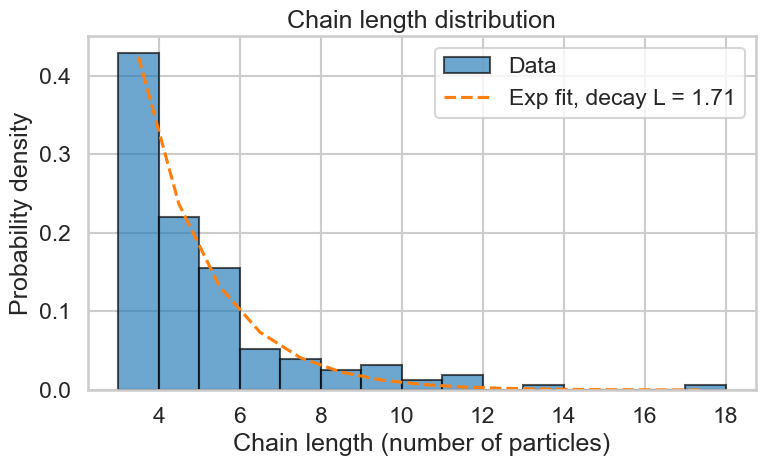

Average chain length: 4.57 particles
Maximum chain length: 17 particles


In [301]:
def plot_chain_length_distribution(chains: List[List[int]], save_path: Path | None = None):
    lengths = np.array([len(c) for c in chains], dtype=int)
    if len(lengths) == 0:
        print("No chains to plot.")
        return

    plt.figure(figsize=(8, 5))
    bins = range(lengths.min(), lengths.max() + 2)
    plt.hist(lengths, bins=bins, density=True, alpha=0.65, edgecolor="black", label="Data")

    if SCIPY_AVAILABLE and len(np.unique(lengths)) > 2:
        def exponential_func(x, a, b):
            return a * np.exp(-b * x)
        counts, bin_edges = np.histogram(lengths, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        try:
            popt, _ = curve_fit(exponential_func, bin_centers, counts, maxfev=10000)
            plt.plot(bin_centers, exponential_func(bin_centers, *popt), linestyle="--", label=f"Exp fit, decay L = {1/popt[1]:.2f}")
        except Exception as e:
            print(f"Could not fit exponential: {e}")

    plt.title("Chain length distribution")
    plt.xlabel("Chain length (number of particles)")
    plt.ylabel("Probability density")
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Average chain length: {np.mean(lengths):.2f} particles")
    print(f"Maximum chain length: {np.max(lengths)} particles")

plot_chain_length_distribution(chains, output_dir / "chain_length_distribution.png")


## Figure 6 — Orientation vs. tortuosity

This summarizes chain architecture.

- Orientation near \(0^\circ\): chain is close to vertical.
- Tortuosity near 1: chain is nearly straight.
- Higher tortuosity: chain is more curved or arch-like.


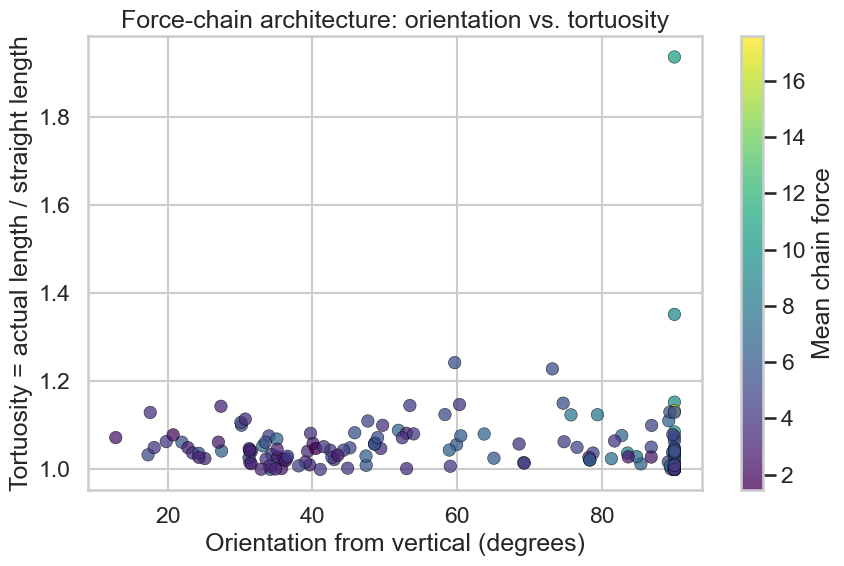

In [302]:
def plot_orientation_vs_tortuosity(chain_df: pd.DataFrame, save_path: Path | None = None):
    if chain_df.empty:
        print("No chain metrics to plot.")
        return

    plt.figure(figsize=(9, 6))
    sc = plt.scatter(
        chain_df["orientation_from_vertical_deg"],
        chain_df["tortuosity"],
        c=chain_df["mean_chain_force"],
        cmap="viridis",
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
    )
    plt.colorbar(sc, label="Mean chain force")
    plt.title("Force-chain architecture: orientation vs. tortuosity")
    plt.xlabel("Orientation from vertical (degrees)")
    plt.ylabel("Tortuosity = actual length / straight length")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

plot_orientation_vs_tortuosity(chain_df, output_dir / "orientation_vs_tortuosity.png")


## Figure 7 — Coordination number \(Z\)

The coordination number \(Z\) is the number of contacts for a particle. This figure compares all particles to particles that belong to force chains.


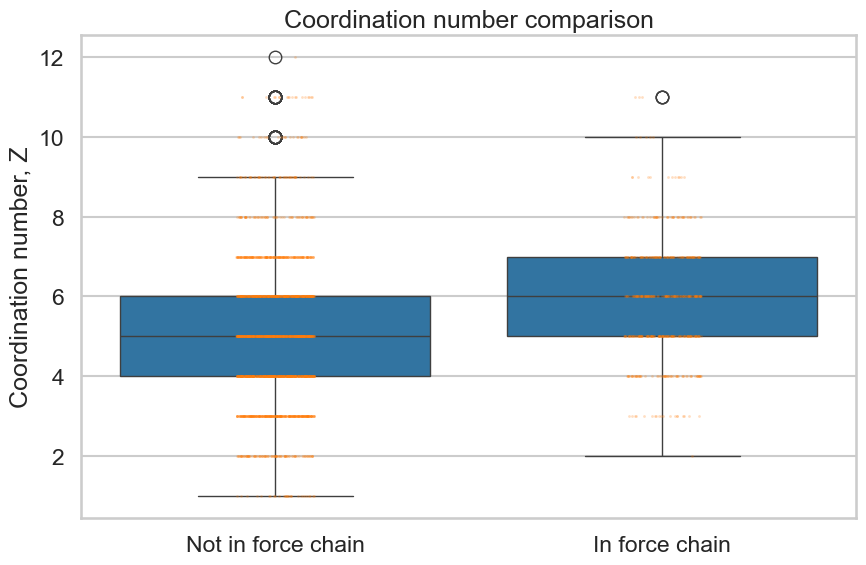

Mean Z, all particles: 5.16
Mean Z, force-chain particles: 5.91


In [303]:
def plot_coordination_number(coord_df: pd.DataFrame, save_path: Path | None = None):
    if coord_df.empty:
        print("No coordination data to plot.")
        return

    all_z = coord_df["coordination_number"].to_numpy()
    chain_z = coord_df.loc[coord_df["in_force_chain"], "coordination_number"].to_numpy()

    plt.figure(figsize=(9, 6))
    sns.boxplot(data=coord_df, x="in_force_chain", y="coordination_number")
    sns.stripplot(data=coord_df, x="in_force_chain", y="coordination_number", alpha=0.25, size=2)
    plt.xticks([0, 1], ["Not in force chain", "In force chain"])
    plt.xlabel("")
    plt.ylabel("Coordination number, Z")
    plt.title("Coordination number comparison")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Mean Z, all particles: {np.mean(all_z):.2f}")
    print(f"Mean Z, force-chain particles: {np.mean(chain_z):.2f}")

plot_coordination_number(coord_df, output_dir / "coordination_number_Z.png")


## Figure 8 — Base pressure map

This estimates where load is transmitted to the floor. Bright cells indicate larger estimated vertical base force.


Saved interactive base-pressure map to force_chain_demo_output_min/base_pressure_map.html


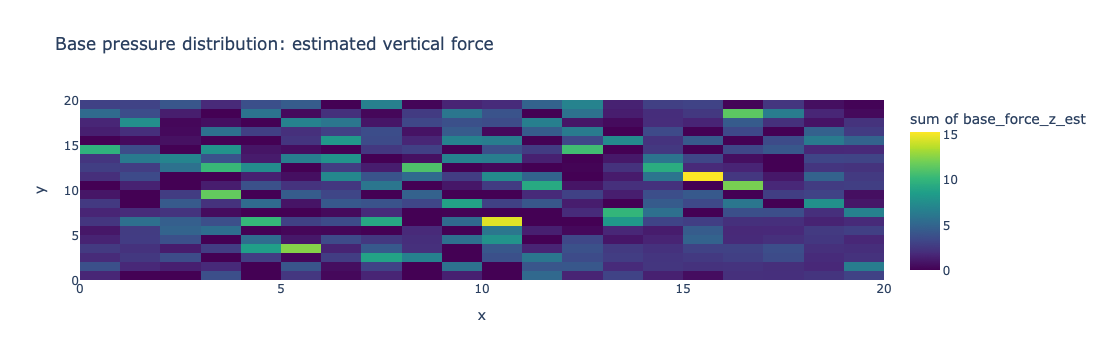

In [304]:
def plot_base_pressure_map(base_df: pd.DataFrame, save_html: Path | None = None):
    if base_df.empty:
        print("No base particles found. Check cfg.z_floor and cfg.base_tolerance.")
        return

    if PLOTLY_AVAILABLE:
        fig = px.density_heatmap(
            base_df,
            x="x", y="y", z="base_force_z_est",
            nbinsx=30, nbinsy=30,
            color_continuous_scale="Viridis",
            title="Base pressure distribution: estimated vertical force",
        )
        fig.update_layout(xaxis_title="x", yaxis_title="y")
        if save_html:
            fig.write_html(str(save_html))
            print(f"Saved interactive base-pressure map to {save_html}")
        fig.show()
    else:
        plt.figure(figsize=(7, 6))
        plt.hist2d(base_df["x"], base_df["y"], weights=base_df["base_force_z_est"], bins=30)
        plt.colorbar(label="Estimated vertical base force")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Base pressure distribution")
        plt.tight_layout()
        plt.show()

plot_base_pressure_map(base_df, output_dir / "base_pressure_map.html")


## Figure 9 — Base pressure versus force-chain anchor positions

This overlays the terminal points of extracted force chains on the base pressure map. It is the direct visual test of whether force chains terminate where the floor feels large loads.


Saved interactive anchor overlay to force_chain_demo_output_min/base_pressure_with_chain_anchors.html


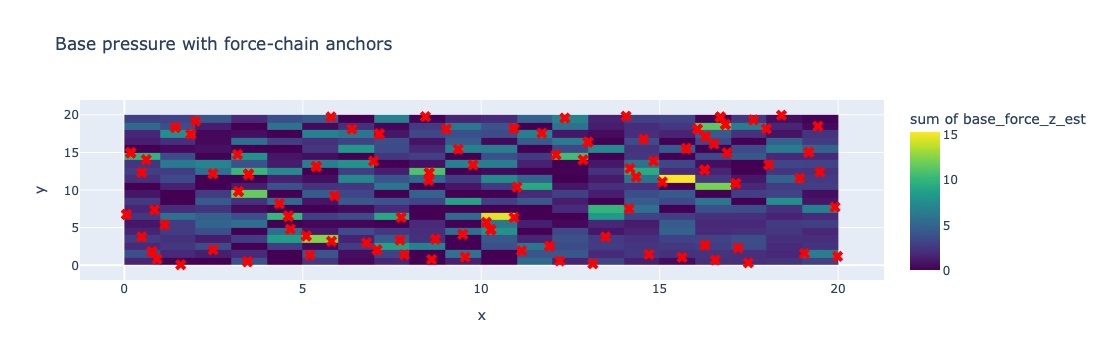

Found 129 chain anchors at the base.


,chain_id,tip,particle_id,x,y,z
0,0,start,277,10.268600,4.71776,0.499915
1,0,end,102,0.057984,6.74477,0.499978
2,1,start,163,19.489300,12.38670,0.499962
3,1,end,97,16.700600,19.69330,0.499967
4,2,start,265,8.435190,19.76130,0.499963


In [305]:
def find_chain_base_anchors(chains: List[List[int]], positions: PositionDict, cfg: PipelineConfig) -> pd.DataFrame:
    anchors = []
    for chain_id, c in enumerate(chains):
        for tip_label, tip in [("start", c[0]), ("end", c[-1])]:
            if tip not in positions:
                continue
            x, y, z = positions[tip]
            if abs(z - cfg.z_floor) <= cfg.base_tolerance:
                anchors.append({
                    "chain_id": chain_id,
                    "tip": tip_label,
                    "particle_id": int(tip),
                    "x": x, "y": y, "z": z,
                })
    return pd.DataFrame(anchors)


def plot_base_pressure_with_chain_anchors(base_df: pd.DataFrame, chains: List[List[int]], positions: PositionDict, cfg: PipelineConfig, save_html: Path | None = None):
    anchors_df = find_chain_base_anchors(chains, positions, cfg)

    if base_df.empty:
        print("No base pressure data found.")
        return anchors_df

    if PLOTLY_AVAILABLE:
        fig = px.density_heatmap(
            base_df,
            x="x", y="y", z="base_force_z_est",
            nbinsx=30, nbinsy=30,
            color_continuous_scale="Viridis",
            title="Base pressure with force-chain anchors",
        )
        if not anchors_df.empty:
            fig.add_scatter(
                x=anchors_df["x"], y=anchors_df["y"],
                mode="markers",
                marker=dict(color="red", size=10, symbol="x"),
                name="Force-chain anchors",
                text=[f"chain {cid}, particle {pid}" for cid, pid in zip(anchors_df["chain_id"], anchors_df["particle_id"])],
            )
        fig.update_layout(xaxis_title="x", yaxis_title="y")
        if save_html:
            fig.write_html(str(save_html))
            print(f"Saved interactive anchor overlay to {save_html}")
        fig.show()
    else:
        plt.figure(figsize=(7, 6))
        plt.hist2d(base_df["x"], base_df["y"], weights=base_df["base_force_z_est"], bins=30)
        plt.colorbar(label="Estimated vertical base force")
        if not anchors_df.empty:
            plt.scatter(anchors_df["x"], anchors_df["y"], marker="x", s=80)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Base pressure with force-chain anchors")
        plt.tight_layout()
        plt.show()

    print(f"Found {len(anchors_df)} chain anchors at the base.")
    return anchors_df

anchors_df = plot_base_pressure_with_chain_anchors(base_df, chains, pos, cfg, output_dir / "base_pressure_with_chain_anchors.html")
anchors_df.head()


## Figure 10 — Radial/position distribution of base anchors

This is useful if you want to discuss whether chains terminate near the center, walls, or edges.


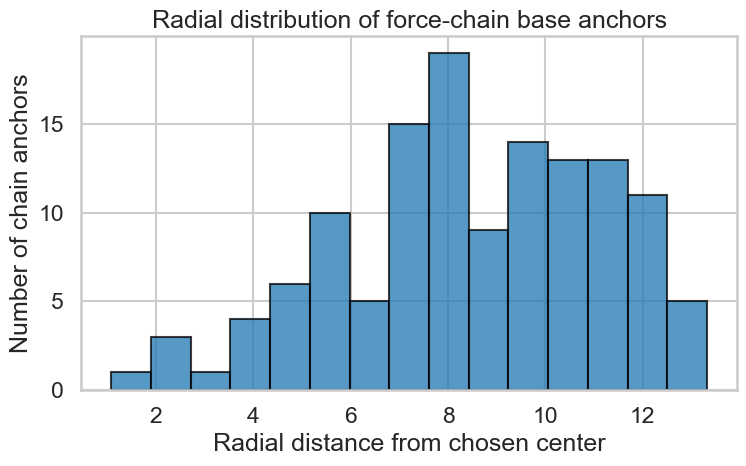

Center used: (np.float64(9.996990775), np.float64(9.992714685))
Mean radial anchor distance: 8.48


In [306]:
def plot_anchor_position_distribution(anchors_df: pd.DataFrame, center: Tuple[float, float] | None = None, save_path: Path | None = None):
    if anchors_df.empty:
        print("No anchors to plot.")
        return

    if center is None:
        # Use midpoint of particle cloud as a default center.
        pts = np.array(list(pos.values()))
        center = (0.5 * (pts[:,0].min() + pts[:,0].max()), 0.5 * (pts[:,1].min() + pts[:,1].max()))

    r = np.sqrt((anchors_df["x"] - center[0])**2 + (anchors_df["y"] - center[1])**2)

    plt.figure(figsize=(8, 5))
    plt.hist(r, bins=15, alpha=0.75, edgecolor="black")
    plt.title("Radial distribution of force-chain base anchors")
    plt.xlabel("Radial distance from chosen center")
    plt.ylabel("Number of chain anchors")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Center used: {center}")
    print(f"Mean radial anchor distance: {np.mean(r):.2f}")

plot_anchor_position_distribution(anchors_df, save_path=output_dir / "base_anchor_radial_distribution.png")


## Optional — Force communities

This is not the same as force chains. Communities show clusters/modules in the contact network. It can be useful as a comparison to your chain-based approach.


In [307]:
def analyze_force_communities(G: nx.Graph, pos: PositionDict, min_size: int = 4):
    try:
        from networkx.algorithms import community
        communities = community.louvain_communities(G, weight="weight", seed=42)
    except Exception as e:
        print(f"Could not run Louvain communities: {e}")
        return None

    print(f"Detected {len(communities)} communities.")

    if PLOTLY_AVAILABLE:
        colors = px.colors.qualitative.Plotly
        fig = go.Figure()
        for i, comm in enumerate(communities):
            if len(comm) < min_size:
                continue
            pts = np.array([pos[p_id] for p_id in comm if p_id in pos])
            if len(pts) == 0:
                continue
            fig.add_trace(go.Scatter3d(
                x=pts[:,0], y=pts[:,1], z=pts[:,2],
                mode="markers",
                marker=dict(size=4, color=colors[i % len(colors)], opacity=0.75),
                name=f"Community {i}",
            ))
        fig.update_layout(title="Force-network communities", scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z"))
        fig.show()

    return communities

# Uncomment to run community visualization:
# communities = analyze_force_communities(G, pos)


## Step 10 — Export tables and summary

This saves the cleaned outputs for later plotting or writing.


In [308]:
contacts.to_csv(output_dir / "contacts_clean.csv", index=False)
edge_df.to_csv(output_dir / "force_chain_edges.csv", index=False)
segment_df.to_csv(output_dir / "segment_geometry.csv", index=False)
chain_df.to_csv(output_dir / "chain_geometry.csv", index=False)
coord_df.to_csv(output_dir / "coordination_numbers.csv", index=False)
base_df.to_csv(output_dir / "base_pressure_estimate.csv", index=False)
anchors_df.to_csv(output_dir / "base_chain_anchors.csv", index=False)

summary = pd.DataFrame([{
    "n_particles_with_positions": len(pos),
    "n_graph_nodes": G.number_of_nodes(),
    "n_contacts": G.number_of_edges(),
    "chain_percentile": cfg.chain_percentile,
    "ebc_threshold": ebc_threshold,
    "n_backbone_edges": H.number_of_edges(),
    "n_chains": len(chains),
    "mean_chain_length_particles": chain_df["n_particles"].mean() if not chain_df.empty else np.nan,
    "mean_tortuosity": chain_df["tortuosity"].mean() if not chain_df.empty else np.nan,
    "mean_orientation_from_vertical_deg": chain_df["orientation_from_vertical_deg"].mean() if not chain_df.empty else np.nan,
    "mean_all_coordination_Z": coord_df["coordination_number"].mean() if not coord_df.empty else np.nan,
    "mean_chain_coordination_Z": coord_df.loc[coord_df["in_force_chain"], "coordination_number"].mean() if not coord_df.empty else np.nan,
    "mean_all_contact_force": edge_df["F"].mean() if not edge_df.empty else np.nan,
    "mean_chain_contact_force": get_chain_contact_forces(G, chains).mean() if len(chains) else np.nan,
    "n_base_particles": len(base_df),
    "n_base_chain_anchors": len(anchors_df),
}])
summary.to_csv(output_dir / "force_chain_summary.csv", index=False)

print(f"Saved outputs to: {output_dir.resolve()}")
summary


Saved outputs to: /Users/tatiana/lammps/spheres/ForceChains/force_chain_demo_output_min


,n_particles_with_positions,n_graph_nodes,n_contacts,chain_percentile,ebc_threshold,n_backbone_edges,n_chains,mean_chain_length_particles,mean_tortuosity,mean_orientation_from_vertical_deg,mean_all_coordination_Z,mean_chain_coordination_Z,mean_all_contact_force,mean_chain_contact_force,n_base_particles,n_base_chain_anchors
0,2669,2657,6853,90.0,0.004291,686,154,4.571429,1.056145,60.076801,5.158449,5.911824,1.676874,5.903702,406,129




- **Network construction:** particles are nodes and contacts are edges.
- **Physical weighting:** strong contacts have small path length because `weight = 1/F`.
- **Backbone identification:** edge betweenness centrality finds contacts that participate in many strong shortest paths.
- **Chain extraction:** high-EBC edges are walked into locally straight chains using an angular cutoff.
- **Mechanical validation:** chain contacts should carry more force than the average contact.
- **Geometry validation:** bend angle, orientation, tortuosity, and chain length describe whether the backbone is pillar-like, arch-like, or mesh-like.
- **Pile-scale validation:** base pressure with chain anchors tests whether detected chains actually terminate at high-load floor regions.
- **Coordination number:** \(Z\) compares how connected chain particles are relative to the whole contact network.


In [309]:
import pickle
from pathlib import Path

snapshot_dir = Path("comparison_snapshots")
snapshot_dir.mkdir(exist_ok=True)

def save_run_snapshot(label):
    snapshot = {
        "pos": pos,
        "chains": chains,
        "G": G,
        "ebc": ebc,
    }

    with open(snapshot_dir / f"{label}.pkl", "wb") as f:
        pickle.dump(snapshot, f)

    print(f"Saved {label}.pkl")

In [310]:
save_run_snapshot("low_friction")
# save_run_snapshot("high_friction")

Saved low_friction.pkl


In [311]:
#Load pkl files
with open("comparison_snapshots/low_friction.pkl", "rb") as f:
    low = pickle.load(f)

with open("comparison_snapshots/high_friction.pkl", "rb") as f:
    high = pickle.load(f)

chains_low = low["chains"]
pos_low = low["pos"]

chains_high = high["chains"]
pos_high = high["pos"]

Low friction angle count: 396
High friction angle count: 77
Low friction mean angle: 20.097478716590523
High friction mean angle: 28.645567803177723


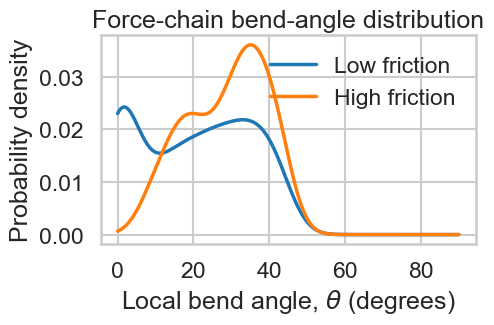

Low friction mean r/R: 0.5771592470302985
High friction mean r/R: 0.6526272749945112


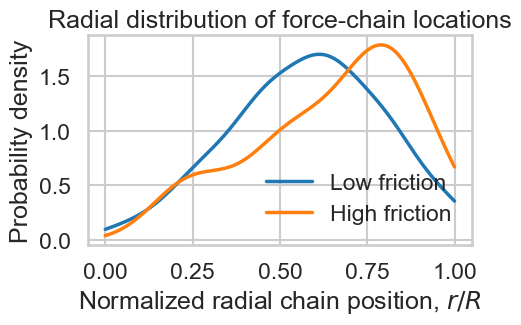

Low friction chain center count: 154
High friction chain center count: 66
Low friction mean r/R: 0.5771592470302985
High friction mean r/R: 0.6526272749945112


In [319]:
import numpy as np
import matplotlib.pyplot as plt

# Optional but recommended for smooth density curves
from scipy.stats import gaussian_kde


# ============================================================
# 1. Helper functions
# ============================================================

def edge_key(a, b):
    return tuple(sorted((int(a), int(b))))


def unit_vector(v):
    return v / (np.linalg.norm(v) + 1e-12)


def bend_angle_deg(pos_a, pos_b, pos_c):
    """
    Local bend angle between a-b and b-c.
    0 degrees = straight.
    Larger angle = more curved/bent chain.
    """
    e1 = unit_vector(pos_b - pos_a)
    e2 = unit_vector(pos_c - pos_b)

    dot = np.clip(np.dot(e1, e2), -1.0, 1.0)
    theta = np.degrees(np.arccos(dot))

    return theta


def get_chain_angles(chains, pos):
    """
    Returns all local bend angles from a list of chains.
    """
    angles = []

    for chain in chains:
        if len(chain) < 3:
            continue

        for i in range(1, len(chain) - 1):
            a = chain[i - 1]
            b = chain[i]
            c = chain[i + 1]

            if a in pos and b in pos and c in pos:
                theta = bend_angle_deg(pos[a], pos[b], pos[c])
                angles.append(theta)

    return np.array(angles)


def get_chain_center_positions(chains, pos):
    #returns x,y,z center-of-mass position for each chain.
    centers = []

    for chain in chains:
        pts = [pos[n] for n in chain if n in pos] #get positions from id's

        if len(pts) == 0:
            continue

        pts = np.array(pts) #->numpy
        centers.append(np.mean(pts, axis=0)) #compute average for each coordinate 

    return np.array(centers) #return all chain centers


def radial_positions_from_centers(centers, x_center=None, y_center=None):
    #Converts chain center positions to radial distance from pile center.
    #How far is a chain from the average chain location in this same dataset? Measures spread
    #Chain dispersion
    #Is the force network becoming less concentrated around the center?
    
    #Isolates internal structure
    if len(centers) == 0:
        return np.array([])
    # x and y from centers
    x = centers[:, 0]
    y = centers[:, 1]

    #this calculates the mean/centroid of chain centers
    #so we can measure the distance to the average location of all chains
    if x_center is None:
        x_center = np.mean(x)

    if y_center is None:
        y_center = np.mean(y)

    r = np.sqrt((x - x_center)**2 + (y - y_center)**2) #compute radial distance

    return r

# def radial_positions_from_centers(centers, x_center, y_center):
#     x = centers[:, 0]
#     y = centers[:, 1]

#     r = np.sqrt((x - x_center)**2 + (y - y_center)**2)

#     return r
    
def plot_two_density_curves(
    data_low,
    data_high,
    xlabel,
    title,
    low_label="Low friction",
    high_label="High friction",
    xlim=None,
    save_path=None
):
    """
    Plots smooth KDE comparison curves.
    """
    data_low = np.asarray(data_low)
    data_high = np.asarray(data_high)

    data_low = data_low[np.isfinite(data_low)]
    data_high = data_high[np.isfinite(data_high)]

    if len(data_low) < 2 or len(data_high) < 2:
        raise ValueError("Need at least 2 data points for each curve.")

    if xlim is None:
        xmin = min(data_low.min(), data_high.min())
        xmax = max(data_low.max(), data_high.max())
    else:
        xmin, xmax = xlim

    x_grid = np.linspace(xmin, xmax, 300)

    kde_low = gaussian_kde(data_low)
    kde_high = gaussian_kde(data_high)

    y_low = kde_low(x_grid)
    y_high = kde_high(x_grid)

    plt.figure(figsize=(5.2, 3.6))
    plt.plot(x_grid, y_low, linewidth=2.5, label=low_label)
    plt.plot(x_grid, y_high, linewidth=2.5, label=high_label)

    plt.xlabel(xlabel)
    plt.ylabel("Probability density")
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# ============================================================
# 2. Inputs you need to replace with your variables
# ============================================================

# Example expected variables:
# chains_low, pos_low
# chains_high, pos_high

# Replace these names if your variables are different.
chains_low = chains_low
pos_low = pos_low
chains_high = chains_high
pos_high = pos_high


# ============================================================
# 3. Chain bend-angle comparison
# ============================================================

angles_low = get_chain_angles(chains_low, pos_low)
angles_high = get_chain_angles(chains_high, pos_high)

print("Low friction angle count:", len(angles_low))
print("High friction angle count:", len(angles_high))

print("Low friction mean angle:", np.mean(angles_low))
print("High friction mean angle:", np.mean(angles_high))

plot_two_density_curves(
    angles_low,
    angles_high,
    xlabel=r"Local bend angle, $\theta$ (degrees)",
    title="Force-chain bend-angle distribution",
    xlim=(0, 90),
    save_path="chain_angle_density_low_vs_high.png"
)


# ============================================================
# 4. Chain radial-position comparison
# ============================================================

centers_low = get_chain_center_positions(chains_low, pos_low)
centers_high = get_chain_center_positions(chains_high, pos_high)

# Use the same pile center for both cases if they share the same box.
# Otherwise, this uses each dataset's chain-center average separately.
r_low = radial_positions_from_centers(centers_low)
r_high = radial_positions_from_centers(centers_high)

# Normalize by each dataset's maximum radial extent
#r_low_norm = r_low / (np.max(r_low) + 1e-12)
#r_high_norm = r_high / (np.max(r_high) + 1e-12)

# r_low = radial_positions_from_centers(centers_low)
# r_high = radial_positions_from_centers(centers_high)

# print("Low friction chain center count:", len(r_low))
# print("High friction chain center count:", len(r_high))

# print("Low friction mean r:", np.mean(r_low))
# print("High friction mean r:", np.mean(r_high))

# plot_two_density_curves(
#     r_low,
#     r_high,
#     xlabel=r"Radial chain position from pile center, $r$",
#     title="Radial distribution of force-chain locations",
#     xlim=None,
#     save_path="chain_radial_position_density_low_vs_high_raw.png"
# )


# centers_low = get_chain_center_positions(chains_low, pos_low)
# centers_high = get_chain_center_positions(chains_high, pos_high)

# all_centers = np.vstack([centers_low, centers_high])

# x_center = np.mean(all_centers[:, 0])
# y_center = np.mean(all_centers[:, 1])

# r_low = radial_positions_from_centers(centers_low, x_center, y_center)
# r_high = radial_positions_from_centers(centers_high, x_center, y_center)

# print("Low friction chain center count:", len(r_low))
# print("High friction chain center count:", len(r_high))

# print("Low friction mean radial position:", np.mean(r_low))
# print("High friction mean radial position:", np.mean(r_high))

# plot_two_density_curves(
#     r_low,
#     r_high,
#     xlabel=r"Radial chain position from pile center, $r$",
#     title="Radial distribution of force-chain locations",
#     xlim=None,
#     save_path="chain_radial_position_density_low_vs_high_raw.png"
# )


r_low = radial_positions_from_centers(centers_low)
r_high = radial_positions_from_centers(centers_high)

r_low_norm = r_low / (np.max(r_low) + 1e-12)
r_high_norm = r_high / (np.max(r_high) + 1e-12)

print("Low friction mean r/R:", np.mean(r_low_norm))
print("High friction mean r/R:", np.mean(r_high_norm))

plot_two_density_curves(
    r_low_norm,
    r_high_norm,
    xlabel=r"Normalized radial chain position, $r/R$",
    title="Radial distribution of force-chain locations",
    xlim=(0, 1),
    save_path="chain_radial_position_density_low_vs_high.png"
)

print("Low friction chain center count:", len(r_low_norm))
print("High friction chain center count:", len(r_high_norm))

print("Low friction mean r/R:", np.mean(r_low_norm))
print("High friction mean r/R:", np.mean(r_high_norm))

# plot_two_density_curves(
#     r_low_norm,
#     r_high_norm,
#     xlabel=r"Normalized radial chain position, $r/R$",
#     title="Radial distribution of force-chain locations",
#     xlim=(0, 1),
#     save_path="chain_radial_position_density_low_vs_high.png"
# )

In [320]:
def get_chain_anchor_positions(chains, pos, n_lowest=1):
    anchors = []

    for chain in chains:
        pts = np.array([pos[n] for n in chain if n in pos]) #get coordinates for each particle in a chain

        if len(pts) == 0:
            continue

        # sort particles in this chain by height z
        pts_sorted = pts[np.argsort(pts[:, 2])]

        # average the lowest n particles
        anchor = pts_sorted[:n_lowest].mean(axis=0)

        anchors.append(anchor)

    return np.array(anchors)

Low friction anchor count: 154
High friction anchor count: 66
Low friction mean anchor r/R: 0.5539819761091839
High friction mean anchor r/R: 0.6053582613031964


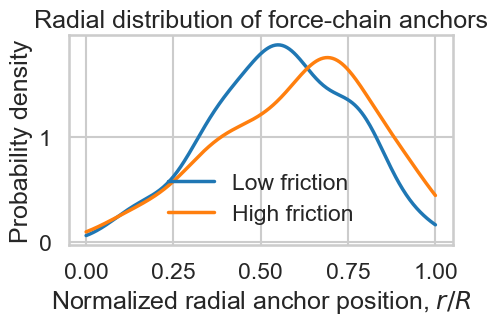

In [321]:
anchors_low = get_chain_anchor_positions(chains_low, pos_low, n_lowest=1)
anchors_high = get_chain_anchor_positions(chains_high, pos_high, n_lowest=1)

r_anchor_low = radial_positions_from_centers(anchors_low)
r_anchor_high = radial_positions_from_centers(anchors_high)

r_anchor_low_norm = r_anchor_low / (np.max(r_anchor_low) + 1e-12)
r_anchor_high_norm = r_anchor_high / (np.max(r_anchor_high) + 1e-12)

print("Low friction anchor count:", len(r_anchor_low_norm))
print("High friction anchor count:", len(r_anchor_high_norm))

print("Low friction mean anchor r/R:", np.mean(r_anchor_low_norm))
print("High friction mean anchor r/R:", np.mean(r_anchor_high_norm))

plot_two_density_curves(
    r_anchor_low_norm,
    r_anchor_high_norm,
    xlabel=r"Normalized radial anchor position, $r/R$",
    title="Radial distribution of force-chain anchors",
    xlim=(0, 1),
    save_path="chain_anchor_radial_distribution_low_vs_high.png"
)

In [322]:
#tips of chains
def get_chain_tip_positions(chains, pos, n_highest=1):
    #position of the highest node

    tips = []

    for chain in chains: #list of force chains

        pts = np.array([pos[n] for n in chain if n in pos]) #particle ids->coordinates for each particle in a chain

        if len(pts) == 0:
            continue

        pts_sorted = pts[np.argsort(pts[:,2])] #sort by z coordinate

        tip = pts_sorted[-n_highest:].mean(axis=0)

        tips.append(tip) #one tip coordinate per chain

    return np.array(tips)

In [334]:
tips_low = get_chain_tip_positions(chains_low, pos_low)
tips_high = get_chain_tip_positions(chains_high, pos_high)

r_tip_low = radial_positions_from_centers(tips_low)
r_tip_high = radial_positions_from_centers(tips_high)

r_tip_low_norm = r_tip_low / (np.max(r_tip_low) + 1e-12)
r_tip_high_norm = r_tip_high / (np.max(r_tip_high) + 1e-12)

#try different normalization to see if centroid affects result
# does not affect result! just like the original calc, tips are just more disperse, same mean tho
def pile_xy_center(pos):
    pts = np.array(list(pos.values()))
    return pts[:, 0].mean(), pts[:, 1].mean()

pile_x_low, pile_y_low = pile_xy_center(pos_low)
pile_x_high, pile_y_high = pile_xy_center(pos_high)

r_tip_low = radial_positions_from_centers(tips_low, pile_x_low, pile_y_low)
r_tip_high = radial_positions_from_centers(tips_high, pile_x_high, pile_y_high)

# Use a comparable normalization
R_low = np.max(radial_positions_from_centers(np.array(list(pos_low.values())), pile_x_low, pile_y_low))
R_high = np.max(radial_positions_from_centers(np.array(list(pos_high.values())), pile_x_high, pile_y_high))

r_tip_low_norm = r_tip_low / (R_low + 1e-12)
r_tip_high_norm = r_tip_high / (R_high + 1e-12)

Low friction tip count: 154
High friction tip count: 66
Low friction mean tip r/R: 0.5393571529557082
High friction mean tip r/R: 0.5439896005883786


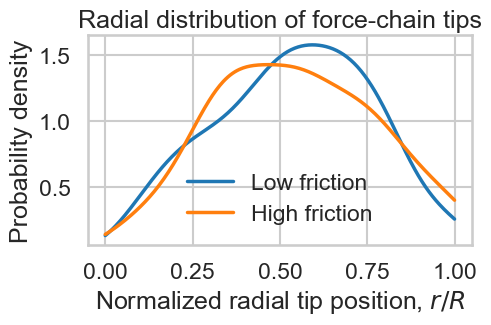

In [335]:
print("Low friction tip count:", len(r_tip_low_norm))
print("High friction tip count:", len(r_tip_high_norm))

print("Low friction mean tip r/R:", np.mean(r_tip_low_norm))
print("High friction mean tip r/R:", np.mean(r_tip_high_norm))

plot_two_density_curves(
    r_tip_low_norm,
    r_tip_high_norm,
    xlabel=r"Normalized radial tip position, $r/R$",
    title="Radial distribution of force-chain tips",
    xlim=(0,1),
)

In [327]:
#movement in z
def chain_vertical_locations(chains, pos):
    """
    For each chain, compute:
    - z_anchor: lowest z value
    - z_center: mean z value
    - z_tip: highest z value
    - dz: vertical span of the chain
    """

    rows = []

    for chain_id, chain in enumerate(chains):
        pts = np.array([pos[n] for n in chain if n in pos])

        if len(pts) < 2:
            continue

        z_values = pts[:, 2]

        rows.append({
            "chain_id": chain_id,
            "z_anchor": np.min(z_values),
            "z_center": np.mean(z_values),
            "z_tip": np.max(z_values),
            "dz": np.max(z_values) - np.min(z_values),
            "n_particles": len(pts),
        })

    return pd.DataFrame(rows)

In [337]:
print(np.std(r_tip_low_norm))
print(np.std(r_tip_high_norm))

0.22305817689887217
0.23115486036370603


In [328]:
z_low = chain_vertical_locations(chains_low, pos_low)
z_high = chain_vertical_locations(chains_high, pos_high)

print("Low friction:")
display(z_low.describe())

print("High friction:")
display(z_high.describe())

Low friction:


,chain_id,z_anchor,z_center,z_tip,dz,n_particles
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,76.500000,1.015540,1.620992,2.268078,1.252538,4.571429
std,44.600075,0.753238,0.954377,1.342761,1.061955,2.263253
min,0.000000,0.499841,0.499938,0.499945,0.000006,3.000000
25%,38.250000,0.499929,0.616085,0.896631,0.055530,3.000000
50%,76.500000,0.499955,1.357371,2.191520,1.385905,4.000000
75%,114.750000,1.344980,2.233906,3.193920,1.841657,5.000000
max,153.000000,3.702590,4.450490,5.300050,3.983640,17.000000


High friction:


,chain_id,z_anchor,z_center,z_tip,dz,n_particles
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,32.500000,1.360507,1.798972,2.277874,0.917367,3.166667
std,19.196354,0.848121,0.847209,0.877109,0.598953,0.414481
min,0.000000,0.499929,0.499974,0.499990,0.000010,3.000000
25%,16.250000,0.499971,1.305081,1.459248,0.623250,3.000000
50%,32.500000,1.316460,1.592732,2.178810,0.821323,3.000000
75%,48.750000,1.954247,2.172600,2.734450,1.431416,3.000000
max,65.000000,3.951060,4.482463,4.770040,2.799409,5.000000


In [329]:
for col in ["z_anchor", "z_center", "z_tip", "dz"]:
    print(col)
    print("  low mean :", z_low[col].mean())
    print("  high mean:", z_high[col].mean())
    print("  change   :", z_high[col].mean() - z_low[col].mean())

z_anchor
  low mean : 1.0155402662337663
  high mean: 1.3605072424242426
  change   : 0.34496697619047634
z_center
  low mean : 1.6209916044802855
  high mean: 1.7989722159090908
  change   : 0.1779806114288054
z_tip
  low mean : 2.268078409090909
  high mean: 2.277873787878788
  change   : 0.009795378787878839
dz
  low mean : 1.252538142857143
  high mean: 0.9173665454545454
  change   : -0.3351715974025975


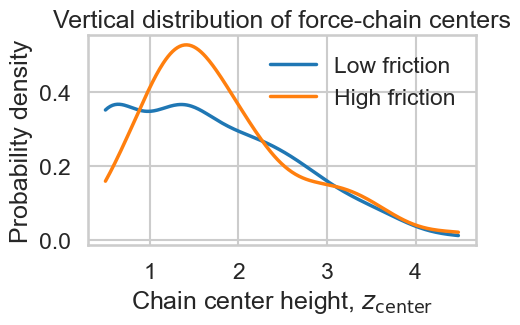

In [330]:
plot_two_density_curves(
    z_low["z_center"],
    z_high["z_center"],
    xlabel=r"Chain center height, $z_{\mathrm{center}}$",
    title="Vertical distribution of force-chain centers",
)

In [331]:
print(z_low["z_center"].mean())
print(z_high["z_center"].mean())

print(z_low["z_anchor"].mean())
print(z_high["z_anchor"].mean())

print(z_low["z_tip"].mean())
print(z_high["z_tip"].mean())

1.6209916044802855
1.7989722159090908
1.0155402662337663
1.3605072424242426
2.268078409090909
2.277873787878788


In [338]:
# -------------------------------
# Tip-anchor radial displacement
# -------------------------------

anchors_low = get_chain_anchor_positions(chains_low, pos_low)
anchors_high = get_chain_anchor_positions(chains_high, pos_high)

tips_low = get_chain_tip_positions(chains_low, pos_low)
tips_high = get_chain_tip_positions(chains_high, pos_high)

def pile_xy_center(pos):
    pts = np.array(list(pos.values()))
    return pts[:, 0].mean(), pts[:, 1].mean()

def pile_radius(pos, x_center, y_center):
    pts = np.array(list(pos.values()))
    r = np.sqrt((pts[:, 0] - x_center)**2 + (pts[:, 1] - y_center)**2)
    return np.max(r)

# pile centers
xc_low, yc_low = pile_xy_center(pos_low)
xc_high, yc_high = pile_xy_center(pos_high)

# pile radii
R_low = pile_radius(pos_low, xc_low, yc_low)
R_high = pile_radius(pos_high, xc_high, yc_high)

# radial positions
r_anchor_low = radial_positions_from_centers(anchors_low, xc_low, yc_low)
r_tip_low = radial_positions_from_centers(tips_low, xc_low, yc_low)

r_anchor_high = radial_positions_from_centers(anchors_high, xc_high, yc_high)
r_tip_high = radial_positions_from_centers(tips_high, xc_high, yc_high)

# normalized radial positions
r_anchor_low_norm = r_anchor_low / (R_low + 1e-12)
r_tip_low_norm = r_tip_low / (R_low + 1e-12)

r_anchor_high_norm = r_anchor_high / (R_high + 1e-12)
r_tip_high_norm = r_tip_high / (R_high + 1e-12)

# displacement from anchor to tip
dr_low = r_tip_low_norm - r_anchor_low_norm
dr_high = r_tip_high_norm - r_anchor_high_norm

print("Low friction mean Δr/R:", np.mean(dr_low))
print("High friction mean Δr/R:", np.mean(dr_high))

print("Low friction std Δr/R:", np.std(dr_low))
print("High friction std Δr/R:", np.std(dr_high))

Low friction mean Δr/R: -0.028431334265972184
High friction mean Δr/R: 0.00950705514362132
Low friction std Δr/R: 0.11376281575988789
High friction std Δr/R: 0.18368739473197152


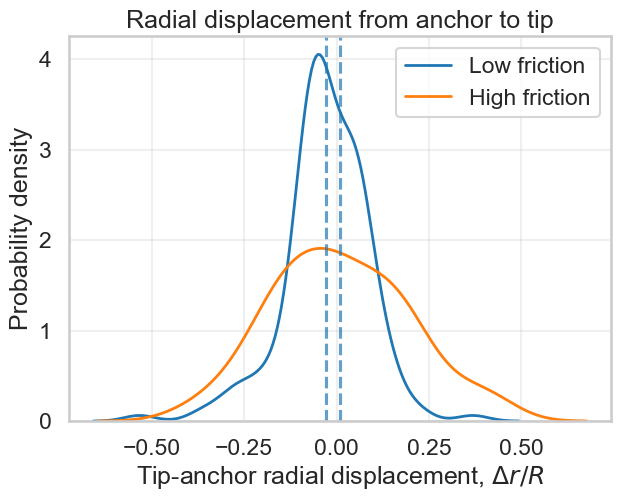

In [339]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.kdeplot(dr_low, label="Low friction", linewidth=2)
sns.kdeplot(dr_high, label="High friction", linewidth=2)

plt.axvline(np.mean(dr_low), linestyle="--", alpha=0.7)
plt.axvline(np.mean(dr_high), linestyle="--", alpha=0.7)

plt.xlabel(r"Tip-anchor radial displacement, $\Delta r/R$")
plt.ylabel("Probability density")
plt.title("Radial displacement from anchor to tip")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()